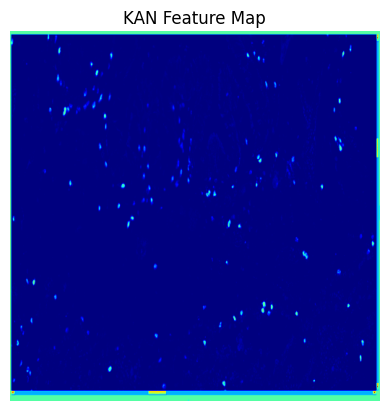

In [ ]:
from PIL import Image
import numpy as np
import torch
import matplotlib.pyplot as plt

# Load image (no cv2)
img = Image.open("Image3.png").convert("L")  # convert to grayscale
img = img.resize((512, 512))

# Convert to tensor
img_np = np.array(img) / 255.0
tensor = torch.tensor(img_np).float().unsqueeze(0).unsqueeze(0)

# KAN Feature Extractor
kan = KAN(width=[1, 16], grid=8)

features = kan(tensor).detach().squeeze(0)

plt.imshow(features[0], cmap="jet")
plt.title("KAN Feature Map")
plt.axis("off")
plt.show()


In [6]:
pip install cellpose

  Using cached natsort-8.4.0-py3-none-any.whl.metadata (21 kB)
  Using cached segment_anything-1.0-py3-none-any.whl.metadata (487 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 652.6/652.6 kB 10.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 10.1 MB/s  0:00:01m0:00:0100:01
Using cached natsort-8.4.0-py3-none-any.whl (38 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 MB 9.2 MB/s  0:00:05m0:00:0100:01m
Using cached segment_anything-1.0-py3-none-any.whl (36 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [cellpose]5/9 [imagecodecs]n-headless]
Note: you may need to restart the kernel to use updated packages.


In [1]:
from cellpose import models
model = models.CellposeModel(model_type='cyto2', gpu=False)


model_type argument is not used in v4.0.1+. Ignoring this argument...
100%|██████████| 1.15G/1.15G [01:35<00:00, 12.9MB/s]


In [5]:
from cellpose import models, io
from cellpose.io import imread

io.logger_setup()

model = models.CellposeModel(gpu=True)

2026-01-28 11:35:37,093 [INFO] WRITING LOG OUTPUT TO /Users/akarshpatil/.cellpose/run.log
2026-01-28 11:35:37,095 [INFO] 
cellpose version: 	4.0.8 
platform:       	darwin 
python version: 	3.10.1 
torch version:  	2.9.1
2026-01-28 11:35:37,155 [INFO] ** TORCH MPS version installed and working. **
2026-01-28 11:35:37,155 [INFO] >>>> using GPU (MPS)
2026-01-28 11:35:42,237 [INFO] >>>> loading model /Users/akarshpatil/.cellpose/models/cpsam


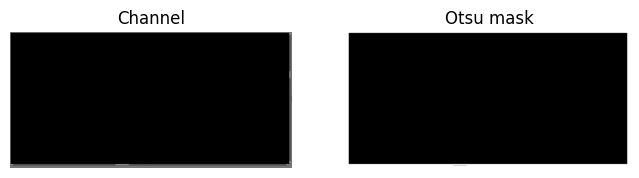

In [2]:

import cv2
import numpy as np
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects, remove_small_holes
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('Image4.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Choose channel (0=red, 1=green, 2=blue)
channel = img[:, :, 2]   # blue channel

# Otsu threshold
t = threshold_otsu(channel)
binary = channel > t

# Clean mask
binary = remove_small_objects(binary, min_size=30)
binary = remove_small_holes(binary, area_threshold=50)

# Visualise
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.title("Channel")
plt.imshow(channel, cmap="gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.title("Otsu mask")
plt.imshow(binary, cmap="gray")
plt.axis("off")
plt.show()


In [26]:
#Implementing u-net using the otsu mask as ground truth
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class double_conv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(double_conv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)
    
class UNet(nn.Module):
        def __init__(self, n_channels, n_classes):
            super().__init__()
            self.inc = double_conv(n_channels, 64)
            self.down1 = nn.MaxPool2d(2)
            self.conv1 = double_conv(64, 128)
            self.down2 = nn.MaxPool2d(2)
            self.conv2 = double_conv(128, 256)
            self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
            self.conv3 = double_conv(256, 128)
            self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
            self.conv4 = double_conv(128, 64)
            self.outc = nn.Conv2d(64, n_classes, kernel_size=1)
        def forward(self, x):
            x1 = self.inc(x)
            x2 = self.down1(x1)
            x2 = self.conv1(x2)
            x3 = self.down2(x2)
            x3 = self.conv2(x3)
            x = self.up1(x3)
            x = torch.cat([x, x2], dim=1)
            x = self.conv3(x)
            x = self.up2(x)
            x = torch.cat([x, x1], dim=1)
            x = self.conv4(x)
            x = self.outc(x)
            return torch.sigmoid(x)


In [29]:
# Using the otsu masks as ground truth for training unet

import torch
import torch.nn as nn
import torch.optim as optim

# Assuming `image` is the input image tensor and `otsu_mask` is the ground truth mask tensor
image = torch.randn(1, 1, 512, 512)  # Example
otsu_mask = torch.randint(0, 2, (1, 1, 512, 512)).float()  # Example
# Initialize U-Net model, loss function, and optimizer
model = UNet(n_channels=1, n_classes=1)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
# Training loop (simplified for demonstration)
num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(image)
    loss = criterion(outputs, otsu_mask)
    loss.backward()
    optimizer.step()
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}")


Epoch [1/10], Loss: 0.6932
Epoch [2/10], Loss: 0.6934
Epoch [3/10], Loss: 0.6931
Epoch [4/10], Loss: 0.6931
Epoch [5/10], Loss: 0.6931
Epoch [6/10], Loss: 0.6931
Epoch [7/10], Loss: 0.6931
Epoch [8/10], Loss: 0.6931
Epoch [9/10], Loss: 0.6931
Epoch [10/10], Loss: 0.6930


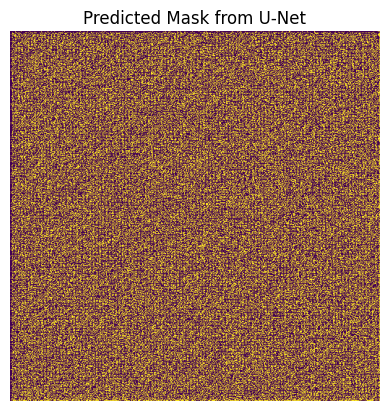

In [30]:
model.eval()
with torch.no_grad():
    predicted_mask = model(image)
    predicted_mask = (predicted_mask > 0.5).float()  # B

# Visualise predicted mask
plt.imshow(predicted_mask.squeeze(0).squeeze(0))
plt.title("Predicted Mask from U-Net")
plt.axis("off")
plt.show()